In [2]:
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
def set_gnuplot_style():
    mpl.rcParams.update({

        # --- Figura ---
        "figure.figsize": (6.0, 4.0),
        "figure.dpi": 120,
        "figure.facecolor": "white",

        # --- Ejes ---
        "axes.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "axes.grid": False,

        # --- Ticks (muy importante para look gnuplot) ---
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "xtick.top": True,
        "ytick.right": True,

        # --- Líneas ---
        "lines.linewidth": 1.5,
        "lines.markersize": 5,
        "lines.markeredgewidth": 0.8,

        # --- Leyenda ---
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.handlelength": 2.5,

        # --- Fuentes ---
        "font.family": "serif",
        "font.size": 12,

        # --- Guardado ---
        "savefig.bbox": "tight",
        "savefig.dpi": 300
    })


# Prevalence chart

In [8]:
def read_prevalence_densities(filename: str) -> pd.DataFrame:
    main_df = pd.read_csv(filename, sep='\s+', names=['t', 'irate', 'idens'])
    rates = np.unique(main_df['irate'])
    df_data = pd.DataFrame(columns=["x", "y", "yerr"])
    for rate in rates:
        last_values = main_df[main_df['irate'] == rate]['idens']
        # display(last_values)
        # df = pd.DataFrame({"x": [float(keyname)]*len(last_values), "y": (last_values)})
        df = pd.DataFrame({"x": [rate], "y": [np.mean(last_values)], "yerr": [np.std(last_values)]})
        df_data = pd.concat([df_data, df], ignore_index=True)
    return df_data
        
weighted = read_prevalence_densities("../density_by_rate_weighted.dat")
unweighted = read_prevalence_densities("../density_by_rate_unweighted.dat")

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_83161/1525586813.py:2: SyntaxWarning: invalid escape sequence '\s'
  main_df = pd.read_csv(filename, sep='\s+', names=['t', 'irate', 'idens'])
/tmp/ipykernel_83161/1525586813.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_data = pd.concat([df_data, df], ignore_index=True)
/tmp/ipykernel_83161/1525586813.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_data = pd.conca

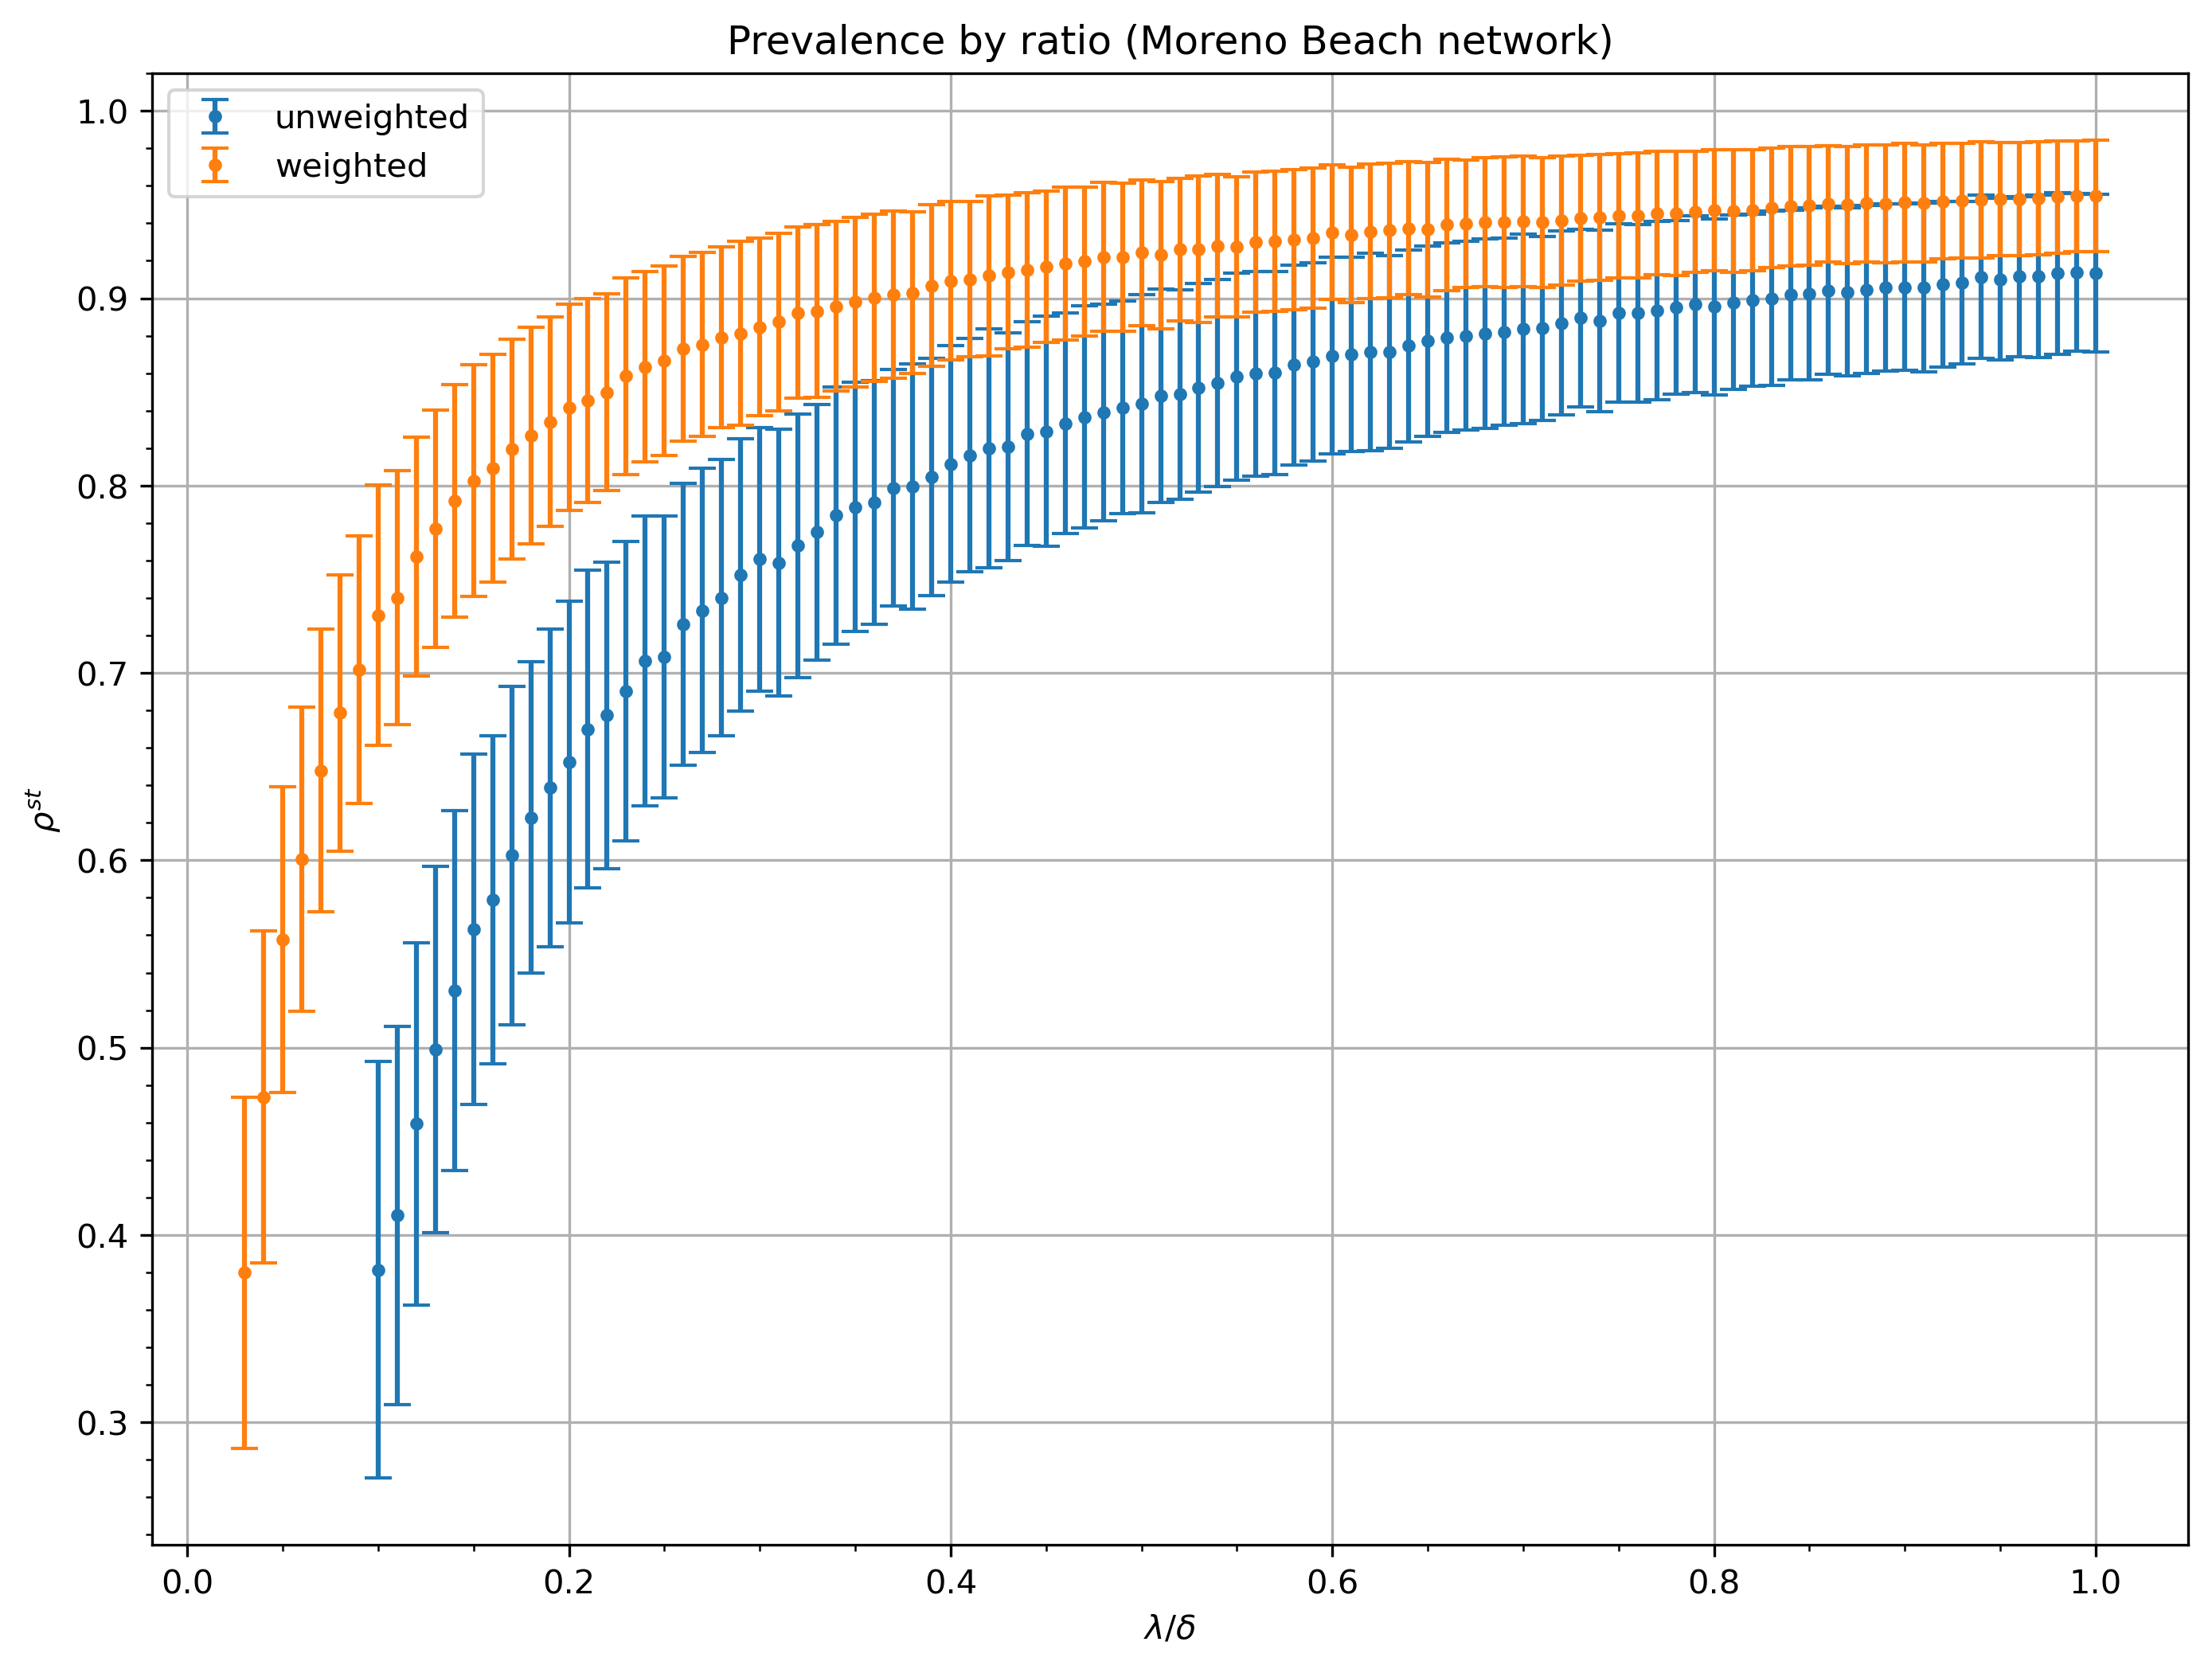

In [14]:
# set_gnuplot_style()
fig, ax = plt.subplots(figsize=(11, 8), dpi=300)
weighted = weighted.sort_values('x')
unweighted = unweighted.sort_values('x')
ax.minorticks_on()
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 0.8)
ax.errorbar(unweighted['x'], unweighted['y'], yerr=unweighted['yerr'], capsize=4, marker='o', linestyle='none', label='unweighted', markersize=3)
ax.errorbar(weighted['x'], weighted['y'], yerr=weighted['yerr'], capsize=4, marker='o', linestyle='none', label='weighted', markersize=3)
ax.set_title("Prevalence by ratio (Moreno Beach network)")
# ax.scatter(df_data['x'], df_data['y'], marker='o')
ax.legend()
ax.set_xlabel(r'$\lambda/\delta$')
ax.set_ylabel(r'$\rho^{st}$')
ax.grid()
plt.show()